<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 4.1}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Giovanni Alejandri Espinosa \\[6pt]
\textbf{Fecha de realización:} & 25/02/2026
\end{array}

</center>

#Introduccion

1. Métricas de Clasificación: La Matriz de ConfusiónLa base de estas métricas es la Matriz de Confusión, que organiza los resultados en Verdaderos Positivos (VP), Verdaderos Negativos (VN), Falsos Positivos (FP) y Falsos Negativos (FN).A. Exactitud (Accuracy)Mide la fracción de predicciones correctas entre el total de casos.$$Exactitud = \frac{VP + VN}{VP + VN + FP + FN}$$Interpretación: Es útil cuando las clases están balanceadas. Sin embargo, puede ser engañosa en datos desbalanceados (ej. si el 99% de los casos son negativos, un modelo que siempre prediga "negativo" tendrá 99% de exactitud, pero será inútil para detectar positivos).

B. Precisión (Precision)Mide la calidad de las predicciones positivas.$$Precisión = \frac{VP}{VP + FP}$$Interpretación: Responde a "¿Qué porcentaje de los que el modelo marcó como positivos son realmente positivos?". Es crucial cuando el costo de un falso positivo es alto (ej. clasificar correo legítimo como spam).

C. Exhaustividad (Recall / Sensibilidad)Mide la capacidad del modelo para encontrar todos los casos positivos.$$Recall = \frac{VP}{VP + FN}$$Interpretación: Responde a "¿Qué porcentaje de los positivos reales logró capturar el modelo?". Es vital cuando el costo de un falso negativo es crítico (ej. detectar una enfermedad grave).


D. Puntuación F1 (F1-Score)Es la media armónica entre la precisión y el recall.$$F1 = 2 \cdot \frac{Precisión \cdot Recall}{Precisión + Recall}$$Interpretación: Proporciona un balance entre ambas métricas. Es preferible a la exactitud cuando existe un desbalance de clases importante.

2. Evaluación de Probabilidades: Curva ROC y AUC
La curva ROC (Receiver Operating Characteristic) grafica la Tasa de Verdaderos Positivos frente a la Tasa de Falsos Positivos para diferentes umbrales de decisión.

AUC (Area Under the Curve): El valor de AUC varía entre 0 y 1. Un modelo perfecto tiene un AUC de 1.0, mientras que uno que predice al azar tiene un AUC de 0.5.

Interpretación: El AUC indica qué tan capaz es el modelo de distinguir entre clases, independientemente del umbral elegido.

3. Métricas de Error (Regresión)Cuando el objetivo es predecir un valor numérico continuo, utilizamos métricas que cuantifican la distancia entre el valor real ($y$) y la predicción ($\hat{y}$).Error Absoluto Medio (MAE): Promedio de las diferencias absolutas. Es robusto ante valores atípicos (outliers).

- Error Cuadrático Medio (MSE): Promedia los cuadrados de los errores. Penaliza más fuertemente los errores grandes.

- Raíz del Error Cuadrático Medio (RMSE): Es la raíz cuadrada del MSE, lo que devuelve la métrica a las unidades originales de los datos.Coeficiente de

- Determinación ($R^2$): Indica la proporción de la varianza de la variable dependiente que es explicada por el modelo. Un $R^2=1$ indica un ajuste perfecto.

4. Correlación de Pearson
Mide el grado de relación lineal entre dos variables continuas.

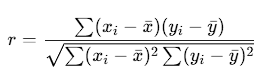

Interpretación: * 1: Correlación lineal positiva perfecta.

0: No hay relación lineal.

-1: Correlación lineal negativa perfecta.

Nota: No implica causalidad y no detecta relaciones no lineales.

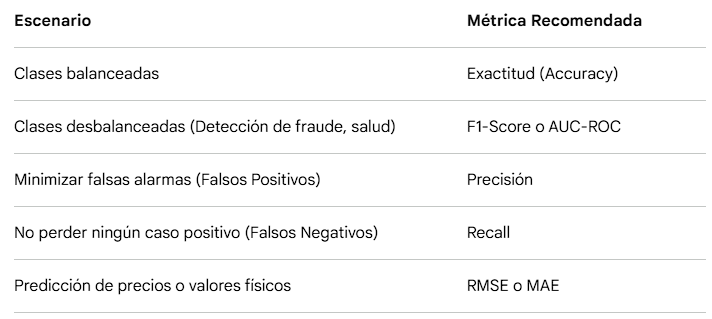

#Desarrollo

1. Bloque de Clasificación
En este ejemplo, utilizaremos un conjunto de datos sintético para evaluar la calidad de un modelo binario.

--- MÉTRICAS DE CLASIFICACIÓN ---
Exactitud (Accuracy): 0.9700
Precisión (Precision): 1.0000
Exhaustividad (Recall): 0.8989
F1-Score: 0.9467


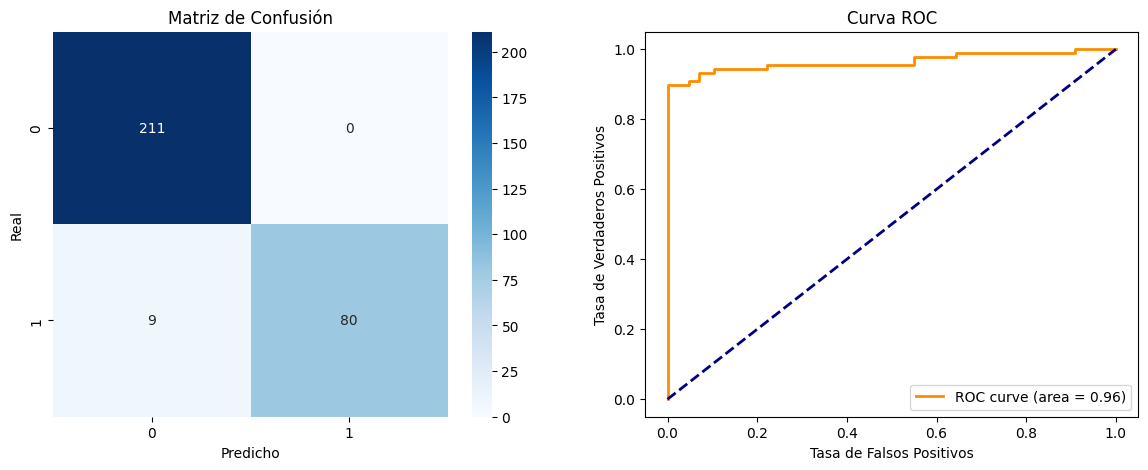

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve, auc)

# 1. Generación de datos (Simulamos un dataset ligeramente desbalanceado)
X, y = make_classification(n_samples=1000, n_features=10, n_clusters_per_class=1,
                           weights=[0.7, 0.3], random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Entrenamiento del modelo
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# 3. Predicciones
y_pred = modelo.predict(X_test)
y_probs = modelo.predict_proba(X_test)[:, 1] # Probabilidades para la curva ROC

# 4. Cálculo de Métricas
print("--- MÉTRICAS DE CLASIFICACIÓN ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisión (Precision): {precision_score(y_test, y_pred):.4f}")
print(f"Exhaustividad (Recall): {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

# 5. Visualización: Matriz de Confusión y Curva ROC
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusión')
ax[0].set_xlabel('Predicho')
ax[0].set_ylabel('Real')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', lw=2,
           label=f'ROC curve (area = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_title('Curva ROC')
ax[1].set_xlabel('Tasa de Falsos Positivos')
ax[1].set_ylabel('Tasa de Verdaderos Positivos')
ax[1].legend(loc="lower right")

plt.show()

2. Bloque de Regresión y Correlación
Aquí analizamos cómo medir el error cuando predecimos valores numéricos y cómo cuantificar la relación lineal entre variables.

--- MÉTRICAS DE REGRESIÓN Y CORRELACIÓN ---
Error Absoluto Medio (MAE): 15.7642
Error Cuadrático Medio (MSE): 394.6943
Raíz del Error Cuadrático Medio (RMSE): 19.8669
Coeficiente de Determinación (R2): 0.9075
Correlación de Pearson: 0.9526


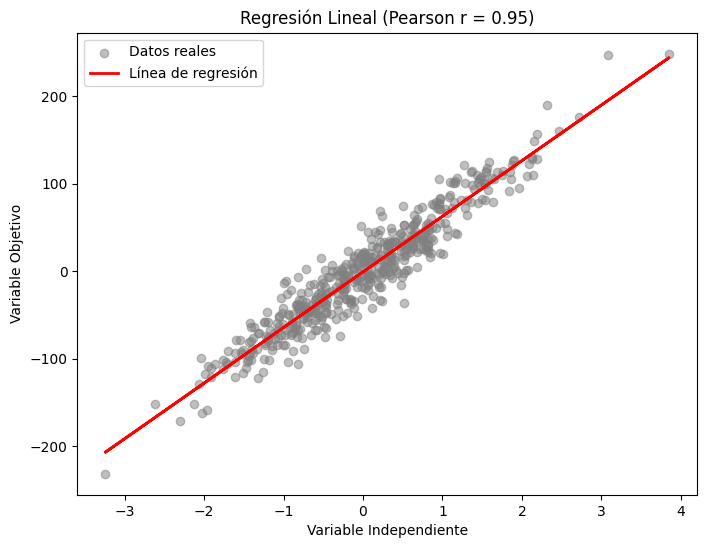

In [3]:
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

# 1. Generación de datos
X_reg, y_reg = make_regression(n_samples=500, n_features=1, noise=20, random_state=42)

# 2. Ajuste del modelo
modelo_reg = LinearRegression()
modelo_reg.fit(X_reg, y_reg)
y_pred_reg = modelo_reg.predict(X_reg)

# 3. Cálculo de Métricas de Error
mae = mean_absolute_error(y_reg, y_pred_reg)
mse = mean_squared_error(y_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg, y_pred_reg)

# 4. Correlación de Pearson
corr, _ = pearsonr(X_reg.flatten(), y_reg)

print("--- MÉTRICAS DE REGRESIÓN Y CORRELACIÓN ---")
print(f"Error Absoluto Medio (MAE): {mae:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")
print(f"Coeficiente de Determinación (R2): {r2:.4f}")
print(f"Correlación de Pearson: {corr:.4f}")

# 5. Visualización
plt.figure(figsize=(8, 6))
plt.scatter(X_reg, y_reg, color='gray', alpha=0.5, label='Datos reales')
plt.plot(X_reg, y_pred_reg, color='red', linewidth=2, label='Línea de regresión')
plt.title(f'Regresión Lineal (Pearson r = {corr:.2f})')
plt.xlabel('Variable Independiente')
plt.ylabel('Variable Objetivo')
plt.legend()
plt.show()

#Análisis de Resultados

- En la Matriz de Confusión: Identifica dónde están los "falsos positivos" y cómo estos afectan la métrica de Precisión.

- En la Curva ROC: ¿Es eficiente o no, y por qué?

- En Regresión ¿En qué se diferencia la penalización que hace el RMSE sobre los errores grandes comparada con el MAE?

#Conclusión

En conclusión, yo creo que evaluar un modelo de Machine Learning no es solo fijarse en un número y ya. Es más bien como conocer a una persona: no puedes quedarte con una sola impresión, necesitas ver todo el contexto.

Por ejemplo, si solo vemos la exactitud, podemos llegar a conclusiones equivocadas. Un modelo que siempre diga “todo está bien” puede parecer bueno porque acierta muchas veces, pero en realidad no sirve para cosas importantes, como detectar enfermedades. Por eso es mejor usar otras métricas como precisión y recall, que nos dan una idea más clara de qué tan bien está funcionando y qué tipo de errores está cometiendo.

Lo mismo pasa con las predicciones numéricas. Hay métricas como MAE y RMSE, y cada una sirve para cosas distintas. Una se enfoca más en los errores grandes y la otra es un poco más tolerante, así que depende de qué tan grave sea equivocarse.

En general, no basta con ver un solo resultado. Hay que analizar varias métricas y pensar en para qué se va a usar el modelo. Al final, un buen modelo no es el que se ve bonito en números, sino el que realmente funciona bien en la práctica.

#Bibliografía



*   Bishop, C.M (2006). Pattern Recognition and Machine Learning. Springer
*   Gerón, A. (2022). Hands-On Machinge Learning with SciKit-Learn, Keras, and Tensor Flow: Concepts, Tools, and Techniques to Build Intelligent Systems (3d ed.). O'Reilly Media
*   Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning: Data Mining, Inference, and Prediction (2nd ed,). Springer
*   James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). And Introduction to Statistical Learning: with Applications in R. Springer








<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>